In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv(r"solar_energy_worldwide.csv")

# Solar Energy Worldwide Data Analysis

## Dataset Overview

This dataset contains information related to solar energy generation, geographical location, sunlight availability, installation cost, annual savings, ROI, CO₂ reduction and solar viability across different cities and countries.

The objective of this analysis is to explore the dataset, handle missing values, perform feature engineering, visualize important patterns, and prepare the data for further analysis and machine learning.

In [15]:
#Basic information about data
print(df.head())

print(df.shape)

print(df.columns)

print(df.info())

print(df.describe())

          City        Country  Latitude  Longitude  Annual_Sunlight_Hours  \
0     New York  United States     40.71     -74.01                 2500.0   
1  Los Angeles  United States     34.05    -118.24                 3200.0   
2        Miami  United States       NaN     -80.19                    NaN   
3      Phoenix  United States     33.45        NaN                 3800.0   
4      Chicago  United States     41.88     -87.63                 2300.0   

   Daily_Peak_Sun_Hours  GHI_kWh_per_m2  Electricity_Price_USD_per_kWh  \
0                   6.8             4.5                           0.15   
1                   8.8             5.8                           0.15   
2                   8.2             5.3                           0.15   
3                  10.4             6.5                           0.15   
4                   6.3             4.2                           0.15   

   Solar_Installations_Count  Avg_System_Cost_USD  Avg_Annual_Production_kWh  \
0           

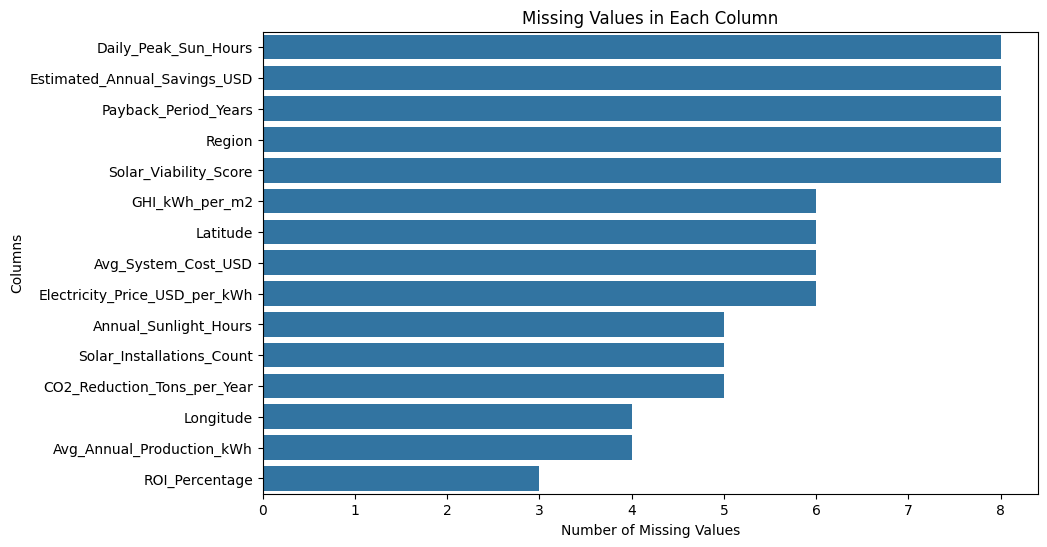

In [16]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=missing.values,
    y=missing.index
)

plt.title("Missing Values in Each Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Columns")

plt.show()

## Missing Value Handling

The dataset contains missing values in both numerical and categorical columns.

- The **Region** column is filled using **Forward Fill** because nearby records generally belong to similar geographical areas.
- Numerical columns are filled using the **median** because it is less affected by extreme values than the mean.

After preprocessing, all missing values are removed successfully.

In [17]:
# Filling categorical column
df["Region"] = df["Region"].ffill()

# Fill numerical columns using median
df["Latitude"] = df["Latitude"].fillna(df["Latitude"].median())
df["Longitude"] = df["Longitude"].fillna(df["Longitude"].median())
df["Annual_Sunlight_Hours"] = df["Annual_Sunlight_Hours"].fillna(df["Annual_Sunlight_Hours"].median())
df["Daily_Peak_Sun_Hours"] = df["Daily_Peak_Sun_Hours"].fillna(df["Daily_Peak_Sun_Hours"].median())
df["GHI_kWh_per_m2"] = df["GHI_kWh_per_m2"].fillna(df["GHI_kWh_per_m2"].median())
df["Electricity_Price_USD_per_kWh"] = df["Electricity_Price_USD_per_kWh"].fillna(df["Electricity_Price_USD_per_kWh"].median())
df["Solar_Installations_Count"] = df["Solar_Installations_Count"].fillna(df["Solar_Installations_Count"].median())
df["Avg_System_Cost_USD"] = df["Avg_System_Cost_USD"].fillna(df["Avg_System_Cost_USD"].median())
df["Avg_Annual_Production_kWh"] = df["Avg_Annual_Production_kWh"].fillna(df["Avg_Annual_Production_kWh"].median())
df["Estimated_Annual_Savings_USD"] = df["Estimated_Annual_Savings_USD"].fillna(df["Estimated_Annual_Savings_USD"].median())
df["Payback_Period_Years"] = df["Payback_Period_Years"].fillna(df["Payback_Period_Years"].median())
df["ROI_Percentage"] = df["ROI_Percentage"].fillna(df["ROI_Percentage"].median())
df["CO2_Reduction_Tons_per_Year"] = df["CO2_Reduction_Tons_per_Year"].fillna(df["CO2_Reduction_Tons_per_Year"].median())
df["Solar_Viability_Score"] = df["Solar_Viability_Score"].fillna(df["Solar_Viability_Score"].median())

In [18]:
df.isnull().sum()

City                             0
Country                          0
Latitude                         0
Longitude                        0
Annual_Sunlight_Hours            0
Daily_Peak_Sun_Hours             0
GHI_kWh_per_m2                   0
Electricity_Price_USD_per_kWh    0
Solar_Installations_Count        0
Avg_System_Cost_USD              0
Avg_Annual_Production_kWh        0
Estimated_Annual_Savings_USD     0
Payback_Period_Years             0
ROI_Percentage                   0
CO2_Reduction_Tons_per_Year      0
Solar_Viability_Score            0
Region                           0
dtype: int64

In [19]:
df["Savings_per_kWh"] = (
    df["Estimated_Annual_Savings_USD"] /
    df["Avg_Annual_Production_kWh"]
)

print(df.head())

          City        Country  Latitude  Longitude  Annual_Sunlight_Hours  \
0     New York  United States     40.71    -74.010                 2500.0   
1  Los Angeles  United States     34.05   -118.240                 3200.0   
2        Miami  United States     36.13    -80.190                 2400.0   
3      Phoenix  United States     33.45     12.075                 3800.0   
4      Chicago  United States     41.88    -87.630                 2300.0   

   Daily_Peak_Sun_Hours  GHI_kWh_per_m2  Electricity_Price_USD_per_kWh  \
0                   6.8             4.5                           0.15   
1                   8.8             5.8                           0.15   
2                   8.2             5.3                           0.15   
3                  10.4             6.5                           0.15   
4                   6.3             4.2                           0.15   

   Solar_Installations_Count  Avg_System_Cost_USD  Avg_Annual_Production_kWh  \
0           

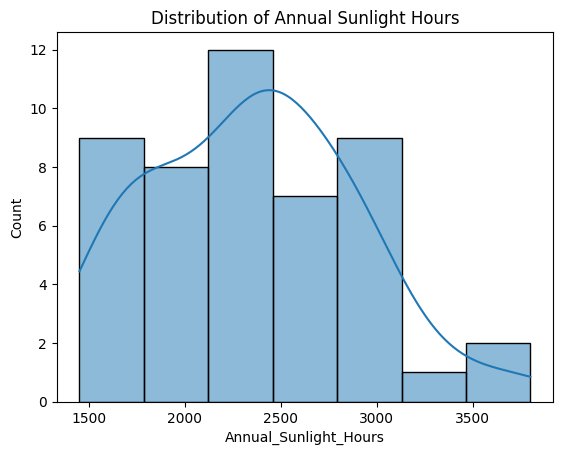

In [20]:
#Histrogram

sns.histplot(df["Annual_Sunlight_Hours"], kde=True)
plt.title("Distribution of Annual Sunlight Hours")
plt.show()

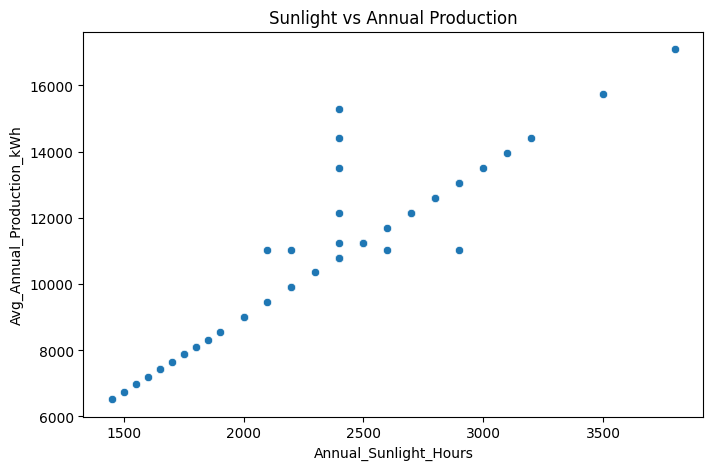

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
data=df,
x="Annual_Sunlight_Hours",
y="Avg_Annual_Production_kWh"
)

plt.title("Sunlight vs Annual Production")

plt.show()

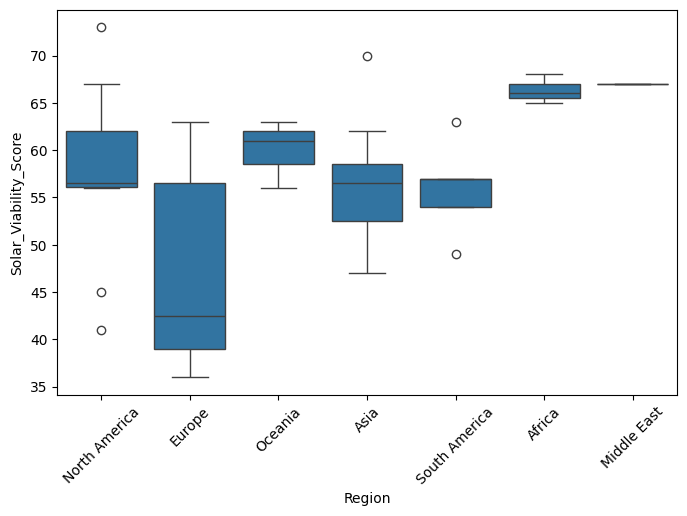

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
data=df,
x="Region",
y="Solar_Viability_Score"
)

plt.xticks(rotation=45)

plt.show()

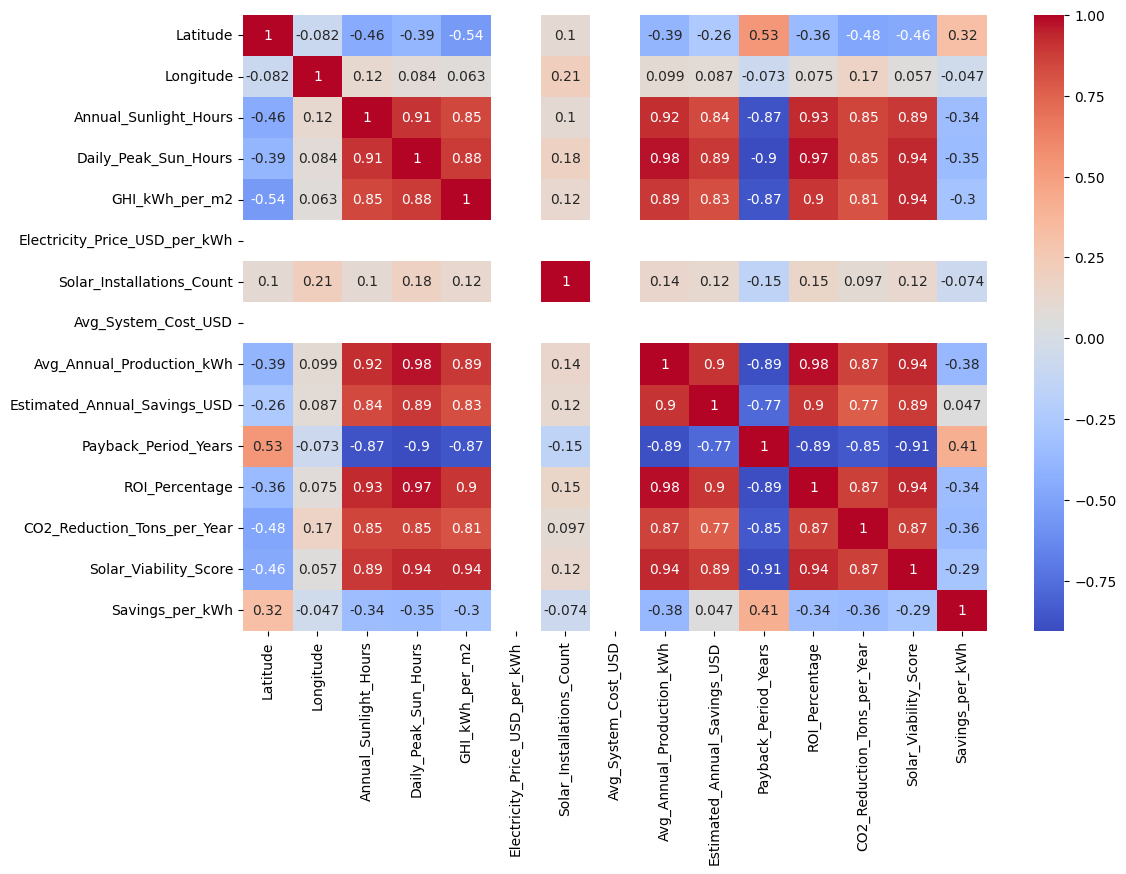

In [23]:
plt.figure(figsize=(12,8))

sns.heatmap(
df.corr(numeric_only=True),
annot=True,
cmap="coolwarm"
)

plt.show()

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = df.select_dtypes(include="number").columns

df[num_cols] = scaler.fit_transform(df[num_cols])

print(df.head())

          City        Country  Latitude  Longitude  Annual_Sunlight_Hours  \
0     New York  United States  0.529681  -1.256588               0.274301   
1  Los Angeles  United States  0.296629  -1.859831               1.581607   
2        Miami  United States  0.369414  -1.340876               0.087543   
3      Phoenix  United States  0.275634  -0.082495               2.702156   
4      Chicago  United States  0.570623  -1.442348              -0.099215   

   Daily_Peak_Sun_Hours  GHI_kWh_per_m2  Electricity_Price_USD_per_kWh  \
0              0.134867        0.000000                            0.0   
1              1.429595        1.392081                            0.0   
2              1.041177        0.856665                            0.0   
3              2.465377        2.141662                            0.0   
4             -0.188814       -0.321249                            0.0   

   Solar_Installations_Count  Avg_System_Cost_USD  Avg_Annual_Production_kWh  \
0           

In [25]:
df = pd.get_dummies(
df,
columns=["Region"],
drop_first=True
)

print(df.head())

          City        Country  Latitude  Longitude  Annual_Sunlight_Hours  \
0     New York  United States  0.529681  -1.256588               0.274301   
1  Los Angeles  United States  0.296629  -1.859831               1.581607   
2        Miami  United States  0.369414  -1.340876               0.087543   
3      Phoenix  United States  0.275634  -0.082495               2.702156   
4      Chicago  United States  0.570623  -1.442348              -0.099215   

   Daily_Peak_Sun_Hours  GHI_kWh_per_m2  Electricity_Price_USD_per_kWh  \
0              0.134867        0.000000                            0.0   
1              1.429595        1.392081                            0.0   
2              1.041177        0.856665                            0.0   
3              2.465377        2.141662                            0.0   
4             -0.188814       -0.321249                            0.0   

   Solar_Installations_Count  Avg_System_Cost_USD  ...  ROI_Percentage  \
0                 

# Final Insights

- The dataset was analysed to understand global solar energy potential and sustainability across different locations.

- Missing values were handled by filling the **Region** column using **Forward Fill** and numerical columns using the **median**, which helps preserve the dataset while reducing the effect of extreme values.

- A new feature, **Savings_per_kWh**, was created to measure the estimated annual savings generated per unit of solar energy production.

- Seaborn visualizations were used to understand the distribution of data and the relationships between important features such as sunlight hours, annual energy production, and solar viability.

- **StandardScaler** was applied to numerical columns to bring all numerical features to a common scale, making the dataset suitable for machine learning algorithms.

- The **Region** column was converted into numerical format using **pd.get_dummies()** so that categorical data can be processed by machine learning models.

- The analysis indicates that locations with higher sunlight availability and better solar irradiance generally have greater energy production, higher annual savings, better return on investment (ROI), and improved solar viability.

- After preprocessing, the dataset is clean, well-structured, and ready for further analysis and machine learning applications.